In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [29]:
#-------------------------------TASK 1 -Exploratory Principal-Component Analysis (PCA)-----------------------------------------

In [6]:
df = pd.read_csv("winequality-red.csv", sep=';') 
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [7]:
df.head()
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
df.isnull().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
# No missing value


In [10]:
# stadarizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['quality'])) 

In [12]:
# checking whether it is standarize or not
print("Means (should be ~0):")
print(np.mean(X_scaled, axis=0))

print("\nStandard Deviations (should be ~1):")
print(np.std(X_scaled, axis=0))

Means (should be ~0):
[ 3.55493551e-16  1.73303106e-16 -8.88733878e-17 -1.24422743e-16
  3.73268229e-16 -6.22113715e-17  4.44366939e-17 -3.47317200e-14
  2.86172309e-15  6.75437748e-16  1.06648065e-16]

Standard Deviations (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
# Covariance matrix
cov_matrix = np.cov(X_scaled, rowvar=False)

In [14]:
# Eigen decomposition
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

In [15]:
# Project onto all components
X_pca = np.dot(X_scaled, eigen_vectors)

In [17]:
print("Covariance matrix shape:", cov_matrix.shape)
print("Eigenvalues shape:", eigen_values.shape)
print("Eigenvectors shape:", eigen_vectors.shape)


Covariance matrix shape: (11, 11)
Eigenvalues shape: (11,)
Eigenvectors shape: (11, 11)


In [19]:
orthogonality = np.dot(eigen_vectors[:, 0], eigen_vectors[:, 1])
print("Dot product of first two eigenvectors (should be close to 0):", orthogonality)

Dot product of first two eigenvectors (should be close to 0): 1.4004860131600733e-16


In [21]:
i = 0  # Try for first eigenpair
left = np.dot(cov_matrix, eigen_vectors[:, i])
right = eigen_values[i] * eigen_vectors[:, i]
print("Are A·v and λ·v close? ", np.allclose(left, right))

Are A·v and λ·v close?  True


In [23]:
# Total variance check
total_variance = np.sum(np.var(X_scaled, axis=0))
eigen_variance = np.sum(eigen_values)
print("Total variance in data:", total_variance)
print("Sum of eigenvalues:", eigen_variance)


Total variance in data: 11.0
Sum of eigenvalues: 11.006883604505633


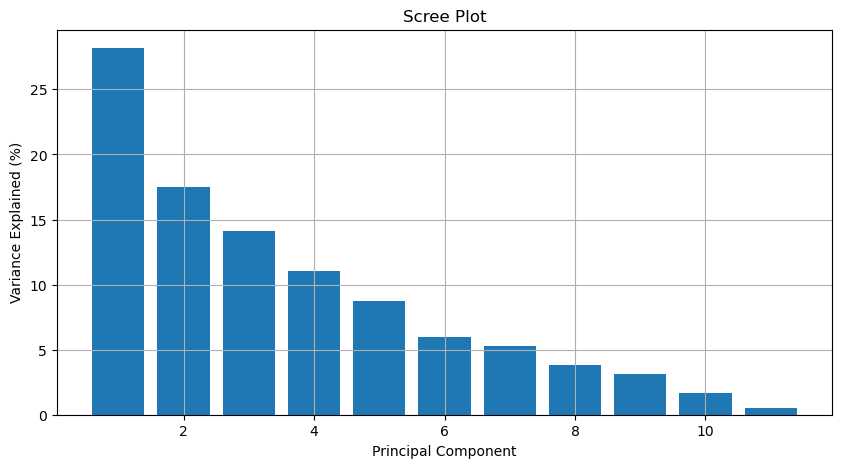

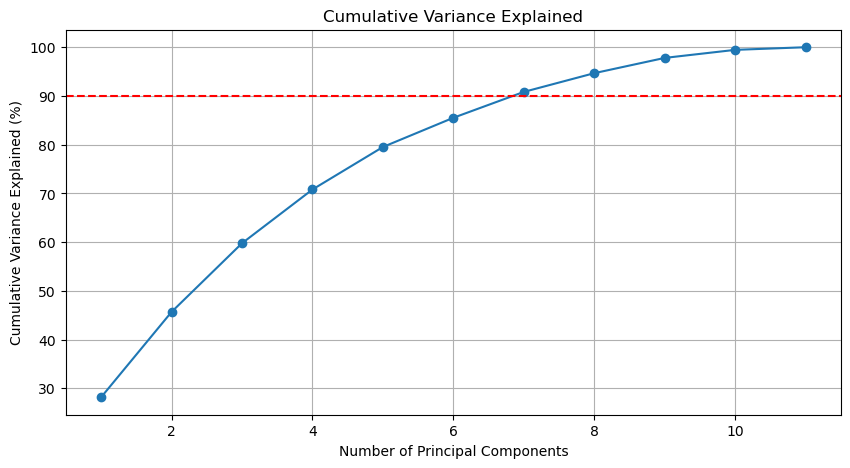

In [24]:
import matplotlib.pyplot as plt

# Explained variance
explained_variance_ratio = eigen_values / np.sum(eigen_values)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Scree plot
plt.figure(figsize=(10,5))
plt.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio * 100)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

# Cumulative variance plot
plt.figure(figsize=(10,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100, marker='o')
plt.axhline(y=90, color='r', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.title('Cumulative Variance Explained')
plt.grid(True)
plt.show()


In [25]:
# Minimum number of components to reach 90% variance
k = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of components to retain (≥90% variance): {k}")


Number of components to retain (≥90% variance): 7


In [26]:
# Select top-k eigenvectors
eigen_vectors_k = eigen_vectors[:, :k]

# Project and reconstruct
X_k = np.dot(X_scaled, eigen_vectors_k)
X_reconstructed = np.dot(X_k, eigen_vectors_k.T)

# Mean Squared Error
mse = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"Mean Squared Error after reconstruction using {k} components: {mse:.4f}")


Mean Squared Error after reconstruction using 7 components: 0.0917


In [30]:
#--------------------------------TASK 2-Image Compression with Truncated SVD----------------------------------------

In [31]:
from PIL import Image
import numpy as np

# Load and convert to grayscale
img = Image.open('SOFTCOMPUTING.jpg').convert('L')  # 'L' mode is for grayscale
img = img.resize((512, 512))  # Resize if needed
A = np.array(img, dtype=np.float64)


In [32]:
print(A.shape)


(512, 512)


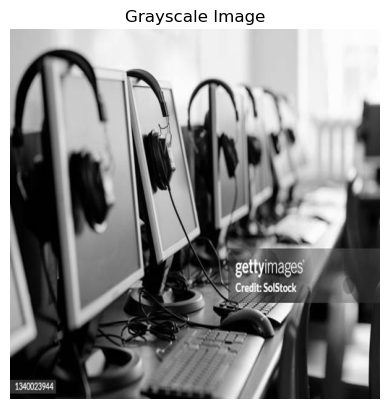

In [33]:
import matplotlib.pyplot as plt

plt.imshow(A, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()


In [34]:
print(f"Data type: {A.dtype}")
print(f"Min pixel value: {np.min(A)}")
print(f"Max pixel value: {np.max(A)}")


Data type: float64
Min pixel value: 0.0
Max pixel value: 255.0


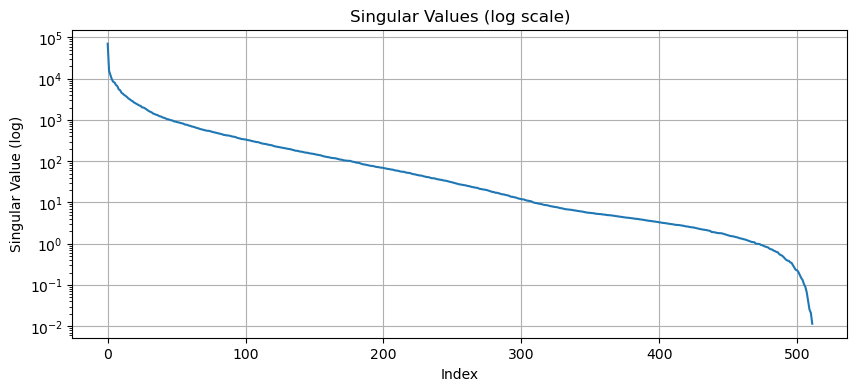

In [35]:
import matplotlib.pyplot as plt
from numpy.linalg import svd

# Compute SVD
U, S, Vt = svd(A, full_matrices=False)

# Plot singular values on log scale
plt.figure(figsize=(10,4))
plt.semilogy(S)
plt.title("Singular Values (log scale)")
plt.xlabel("Index")
plt.ylabel("Singular Value (log)")
plt.grid()
plt.show()


In [36]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def compress_image(U, S, Vt, r):
    Ur = U[:, :r]
    Sr = np.diag(S[:r])
    Vtr = Vt[:r, :]
    Ar = np.dot(Ur, np.dot(Sr, Vtr))
    return Ar

def compression_ratio(m, n, r):
    original = m * n
    compressed = r * (m + n + 1)
    return original / compressed

m, n = A.shape
r_values = [5, 20, 50, 100, 200]

for r in r_values:
    A_r = compress_image(U, S, Vt, r)
    cr = compression_ratio(m, n, r)
    psnr_val = psnr(A, A_r, data_range=255)
    ssim_val = ssim(A, A_r, data_range=255)

    print(f"Rank {r}:")
    print(f"  Compression Ratio: {cr:.2f}")
    print(f"  PSNR: {psnr_val:.2f}")
    print(f"  SSIM: {ssim_val:.4f}")
    print()


Rank 5:
  Compression Ratio: 51.15
  PSNR: 15.87
  SSIM: 0.4435

Rank 20:
  Compression Ratio: 12.79
  PSNR: 22.49
  SSIM: 0.6502

Rank 50:
  Compression Ratio: 5.12
  PSNR: 29.22
  SSIM: 0.8485

Rank 100:
  Compression Ratio: 2.56
  PSNR: 36.94
  SSIM: 0.9603

Rank 200:
  Compression Ratio: 1.28
  PSNR: 50.63
  SSIM: 0.9973



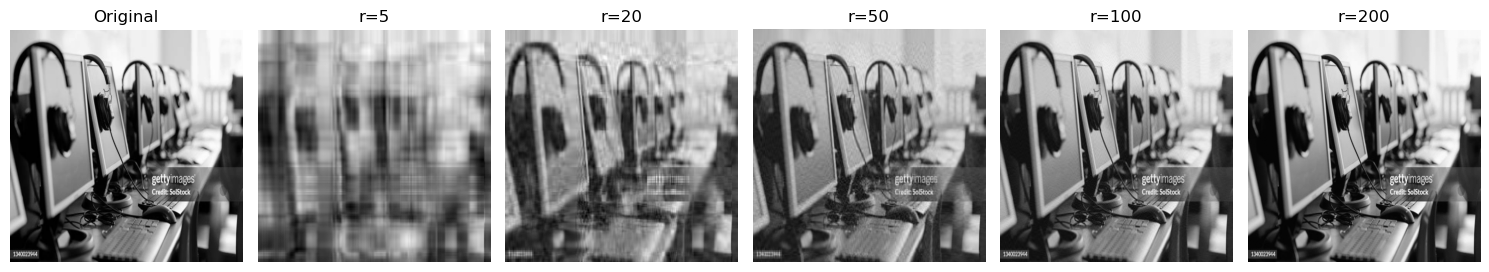

In [37]:
fig, axes = plt.subplots(1, len(r_values)+1, figsize=(15,5))
axes[0].imshow(A, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, r in enumerate(r_values):
    A_r = compress_image(U, S, Vt, r)
    axes[i+1].imshow(A_r, cmap='gray')
    axes[i+1].set_title(f'r={r}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()


In [38]:
#---------------Task 3 – Latent Semantic Analysis (LSA) for Topic Classification (Bonus Question)--------------------

In [50]:
# Load the Dataset & Convert to TF-IDF
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
import time

# Load data
categories = None  # Use all categories
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

# Convert to TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.5)
X_train_tfidf = vectorizer.fit_transform(newsgroups_train.data)
X_test_tfidf = vectorizer.transform(newsgroups_test.data)

# Record original shape
print("Original TF-IDF shape:", X_train_tfidf.shape)


Original TF-IDF shape: (11314, 101322)


In [49]:
from sklearn.decomposition import TruncatedSVD

k = 100
svd = TruncatedSVD(n_components=k, random_state=42)

start = time.time()
X_train_lsa = svd.fit_transform(X_train_tfidf)
X_test_lsa = svd.transform(X_test_tfidf)
print("Time for TruncatedSVD:", time.time() - start)
print("Reduced LSA shape:", X_train_lsa.shape)


Time for TruncatedSVD: 2.7580478191375732
Reduced LSA shape: (11314, 100)



TF-IDF (Baseline) Accuracy: 0.6909
TF-IDF (Baseline) Training time: 11.47 seconds


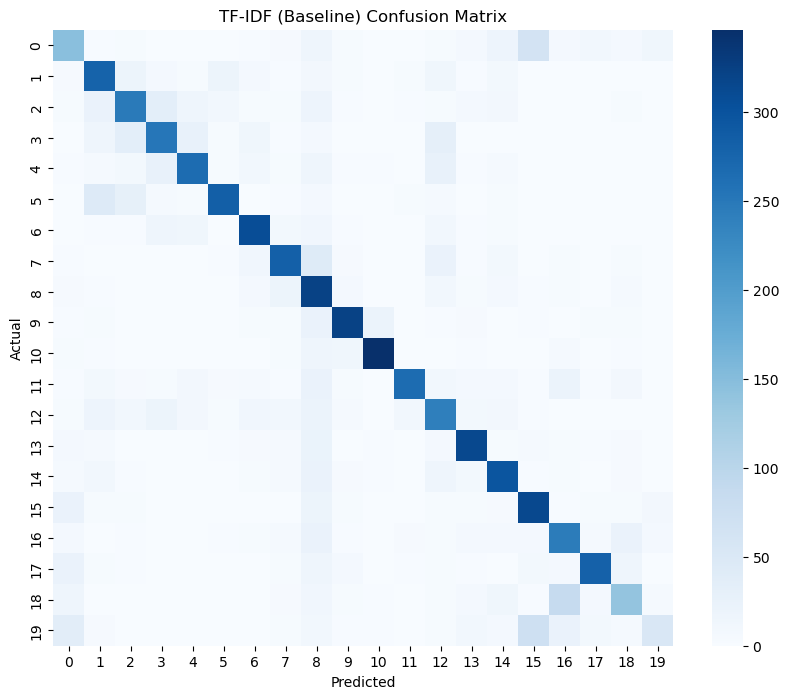


LSA (k=100) Accuracy: 0.6093
LSA (k=100) Training time: 0.45 seconds


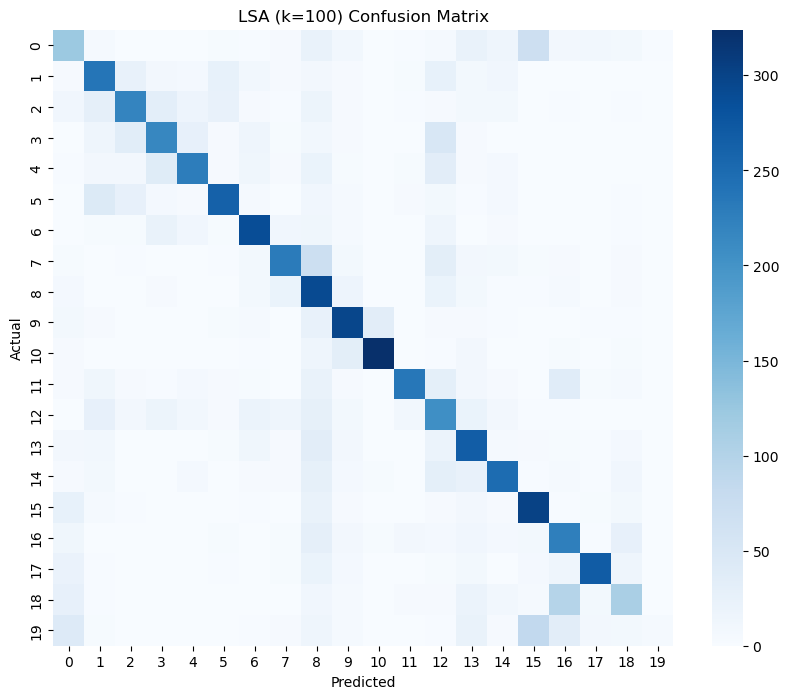

In [51]:
#Train Logistic Regression (Baseline and LSA)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_evaluate(X_train, y_train, X_test, y_test, label="Model"):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    start = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{label} Accuracy: {acc:.4f}")
    print(f"{label} Training time: {train_time:.2f} seconds")

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", annot=False, fmt="d")
    plt.title(f"{label} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, train_time

# Train baseline (TF-IDF)
acc_tfidf, time_tfidf = train_and_evaluate(
    X_train_tfidf, newsgroups_train.target,
    X_test_tfidf, newsgroups_test.target,
    label="TF-IDF (Baseline)"
)

# Train LSA (SVD-reduced)
acc_lsa, time_lsa = train_and_evaluate(
    X_train_lsa, newsgroups_train.target,
    X_test_lsa, newsgroups_test.target,
    label="LSA (k=100)"
)


In [52]:
import pandas as pd

# Summary Table
comparison_df = pd.DataFrame({
    'Model': ['TF-IDF (Baseline)', 'LSA (k=100)'],
    'Accuracy': [acc_tfidf, acc_lsa],
    'Training Time (s)': [time_tfidf, time_lsa],
    'Feature Dimensionality': [X_train_tfidf.shape[1], X_train_lsa.shape[1]]
})

print("\n=== Model Comparison Summary ===")
print(comparison_df.to_string(index=False))



=== Model Comparison Summary ===
            Model  Accuracy  Training Time (s)  Feature Dimensionality
TF-IDF (Baseline)  0.690919          11.471872                  101322
      LSA (k=100)  0.609267           0.454393                     100


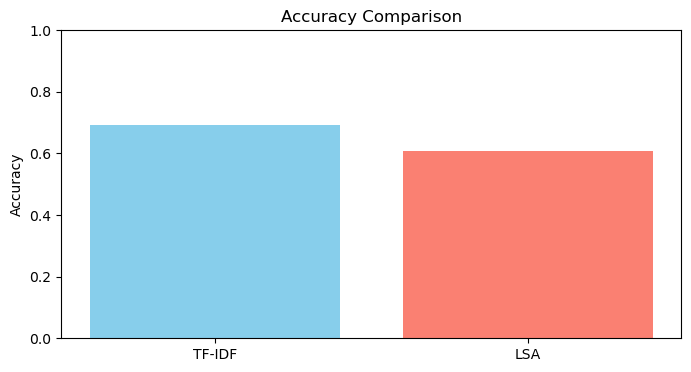

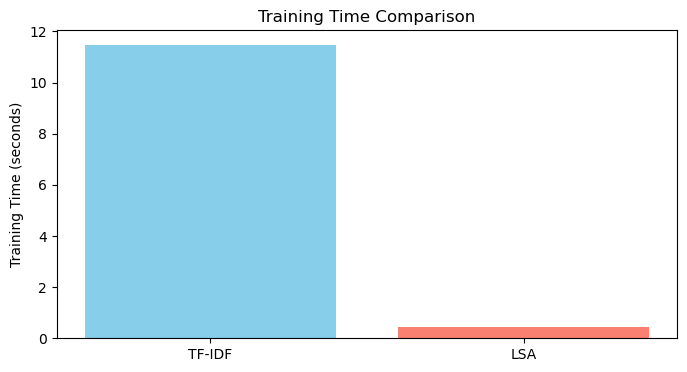

In [53]:
import matplotlib.pyplot as plt

# Accuracy Bar Plot
plt.figure(figsize=(8, 4))
plt.bar(['TF-IDF', 'LSA'], [acc_tfidf, acc_lsa], color=['skyblue', 'salmon'])
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

# Training Time Bar Plot
plt.figure(figsize=(8, 4))
plt.bar(['TF-IDF', 'LSA'], [time_tfidf, time_lsa], color=['skyblue', 'salmon'])
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison')
plt.show()


In [ ]:
#-----------------------------------END--------------------------------------------